# Notebook 5 v2 — Élévation + PU Learning

## Objectif

Compléter le framework du Notebook 3bis avec :
1. **Données d'élévation** (SRTM) pour calculer le D+ et l'abs_grade par arête
2. **PU Learning** (Elkan & Noto 2008) pour apprendre quelles arêtes sont
   "club-worthy" au-delà de simplement "déjà empruntées"
3. **Mode grimpeur** : budget D+ total en paramètre utilisateur

## Changements par rapport à la v1

- On **n'écrase pas** l'heuristique métier, on la complète
- Le `cost_factor_v2` sera : `cost_factor_v1 × (1 - β × score_club_gen)`
  où β ∈ [0, 0.5] contrôle l'influence du modèle appris
- Features **sans** coordonnées brutes pour limiter l'overfit spatial
- Cross-validation spatiale rigoureuse (train Pantin, test Vexin)

## Plan

1. Setup + téléchargement SRTM
2. Calcul D+, grade, alt_std par arête
3. Features pour PU learning (hors géographie pure)
4. Train modèle (Logistic + Gradient Boosting calibrés)
5. Elkan-Noto pour la calibration `P(y=1|x)`
6. Mise à jour de `cost_factor_v2` = cost_factor × (1 - β·score_gen)
7. Diagnostics (AUC, calibration, feature importance)
8. Rapport

## Papiers de référence (rappel)

- **Elkan & Noto (2008)** KDD — PU learning sous SCAR
- **Bekker & Davis (2020)** Machine Learning — survey complet
- **Broach et al. (2012)** — pour les coefficients métier qu'on complète


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import time, os
import warnings
warnings.filterwarnings("ignore")

from sqlalchemy import create_engine, text
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss

from shapely import wkt
import matplotlib.pyplot as plt

DB_CONFIG = {"user": "postgres", "password": "4421",
             "host": "localhost", "port": 5432, "database": "velo_club"}
url = (f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
       f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}")
engine = create_engine(url, pool_pre_ping=True)
DATA_DIR = Path("data/processed"); DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Setup OK")

Setup OK


## 2. Élévation SRTM + calcul D+

On télécharge les tuiles SRTM pour l'IdF puis on échantillonne l'altitude le
long de chaque arête pour calculer le D+ cumulé, le grade moyen et
l'écart-type d'altitude.

In [6]:
import zipfile
from pathlib import Path
import rasterio
from rasterio.merge import merge

# 1. Configuration des dossiers
downloads_dir = Path(r"C:\Users\rapha\Downloads")

data_dir = Path(r"C:\Users\rapha\Desktop\GPX projet\Data\intermediaire")
data_dir.mkdir(parents=True, exist_ok=True) # Crée le dossier s'il n'existe pas

output_path = data_dir / "srtm_idf.tif"

# Liste de tes 6 fichiers ZIP
zip_files = [
    "N48E001.SRTMGL1.hgt.zip", "N48E002.SRTMGL1.hgt.zip", "N48E003.SRTMGL1.hgt.zip",
    "N49E001.SRTMGL1.hgt.zip", "N49E002.SRTMGL1.hgt.zip", "N49E003.SRTMGL1.hgt.zip"
]

print("1. Extraction des fichiers .hgt depuis les ZIP...")
hgt_files = []
for zip_name in zip_files:
    zip_path = downloads_dir / zip_name
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # On extrait tout dans le dossier Téléchargements
        zip_ref.extractall(downloads_dir)
        # On déduit le nom du fichier dézippé (ex: N48E001.hgt)
        hgt_name = zip_name.split('.')[0] + ".hgt"
        hgt_files.append(downloads_dir / hgt_name)

print("2. Lecture des tuiles (les morceaux du puzzle)...")
src_files_to_mosaic = [rasterio.open(hgt) for hgt in hgt_files]

print("3. Fusion de l'Île-de-France en cours...")
mosaic, out_trans = merge(src_files_to_mosaic)

# On prépare les paramètres du nouveau fichier fusionné
out_meta = src_files_to_mosaic[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans
})

print(f"4. Sauvegarde du fichier final : {output_path}...")
with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(mosaic)

# On ferme proprement les fichiers
for src in src_files_to_mosaic:
    src.close()

print("✅ Terminé ! Le fichier srtm_idf.tif est prêt.")

1. Extraction des fichiers .hgt depuis les ZIP...
2. Lecture des tuiles (les morceaux du puzzle)...
3. Fusion de l'Île-de-France en cours...
4. Sauvegarde du fichier final : C:\Users\rapha\Desktop\GPX projet\Data\intermediaire\srtm_idf.tif...
✅ Terminé ! Le fichier srtm_idf.tif est prêt.


In [9]:
import rasterio
from pathlib import Path
import sys

# 1. On définit EXACTEMENT le même chemin que celui utilisé pour créer le fichier
SRTM_PATH = Path(r"C:\Users\rapha\Desktop\GPX projet\Data\intermediaire\srtm_idf.tif")

# 2. On vérifie s'il existe (normalement oui, si tu as bien lancé la cellule de fusion avant)
if not SRTM_PATH.exists():
    print(f"✗ Erreur : Le fichier est introuvable ici : {SRTM_PATH}")
    print("Assure-toi d'avoir bien exécuté la cellule de fusion des ZIP juste avant.")
    # On ne tente pas le téléchargement auto ici car on sait que ça plante sur Windows
    sys.exit("Fichier manquant.")

# 3. Maintenant on l'ouvre
try:
    dem = rasterio.open(SRTM_PATH)
    print(f"✅ SRTM chargé avec succès !")
    print(f"Dimensions : {dem.shape}")
    print(f"Résolution : {dem.res}")
except Exception as e:
    print(f"✗ Erreur lors de l'ouverture du fichier : {e}")

✅ SRTM chargé avec succès !
Dimensions : (7201, 10801)
Résolution : (0.0002777777777777778, 0.0002777777777777778)


In [12]:
# Ajout colonnes d'élévation
with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE osm_edges ADD COLUMN IF NOT EXISTS d_plus_m DOUBLE PRECISION;
        ALTER TABLE osm_edges ADD COLUMN IF NOT EXISTS avg_grade DOUBLE PRECISION;
        ALTER TABLE osm_edges ADD COLUMN IF NOT EXISTS alt_std DOUBLE PRECISION;
    """))

In [13]:
def sample_elevations(geom, dem, pts_per_100m=1):
    """Échantillonne altitudes le long d'une arête en WGS84."""
    n = max(3, int(geom.length * 111000 / 100) * pts_per_100m)
    n = min(n, 30)
    pts = [geom.interpolate(i/(n-1), normalized=True) for i in range(n)]
    coords = [(p.x, p.y) for p in pts]
    try:
        alts = [float(v[0]) for v in dem.sample(coords)]
        alts = [a for a in alts if -1000 < a < 5000]
        return alts
    except Exception:
        return []


def d_plus_stats(alts):
    if len(alts) < 2:
        return 0.0, 0.0, 0.0
    diffs = np.diff(alts)
    d_plus = float(np.sum(np.maximum(diffs, 0)))
    signed = float(alts[-1] - alts[0])
    std = float(np.std(alts))
    return d_plus, signed, std

In [14]:
BATCH = 5000
t0 = time.time()

with engine.connect() as conn:
    n_todo = conn.execute(text("""
        SELECT COUNT(*) FROM osm_edges
        WHERE d_plus_m IS NULL AND geom IS NOT NULL AND is_routable;
    """)).scalar()
print(f"{n_todo:,} arêtes à traiter")

total = 0
while True:
    with engine.connect() as conn:
        batch = pd.read_sql(text("""
            SELECT edge_id, length_m, ST_AsText(geom) AS wkt
            FROM osm_edges
            WHERE d_plus_m IS NULL AND geom IS NOT NULL AND is_routable
            ORDER BY edge_id LIMIT :n;
        """), conn, params={"n": BATCH})
    if len(batch) == 0:
        break

    params = []
    for _, row in batch.iterrows():
        try:
            g = wkt.loads(row["wkt"])
            alts = sample_elevations(g, dem)
            dp, ds, sd = d_plus_stats(alts)
            grade = 100 * ds / max(row["length_m"], 1)
        except Exception:
            dp, grade, sd = 0.0, 0.0, 0.0
        params.append({
            "edge_id": int(row["edge_id"]),
            "d_plus_m": float(dp),
            "avg_grade": float(grade),
            "alt_std": float(sd),
        })

    with engine.begin() as conn:
        conn.execute(text("""
            UPDATE osm_edges
            SET d_plus_m = :d_plus_m, avg_grade = :avg_grade, alt_std = :alt_std
            WHERE edge_id = :edge_id;
        """), params)

    total += len(params)
    el = time.time() - t0
    print(f"  [{total:,}/{n_todo:,}] {total/el:.0f}/s ETA {(n_todo-total)/max(total/el,1):.0f}s")

print(f"\n✓ Terminé en {time.time()-t0:.0f}s")

506,169 arêtes à traiter
  [5,000/506,169] 474/s ETA 1058s
  [10,000/506,169] 535/s ETA 928s
  [15,000/506,169] 573/s ETA 856s
  [20,000/506,169] 613/s ETA 793s
  [25,000/506,169] 633/s ETA 760s
  [30,000/506,169] 661/s ETA 720s
  [35,000/506,169] 675/s ETA 698s
  [40,000/506,169] 689/s ETA 676s
  [45,000/506,169] 695/s ETA 663s
  [50,000/506,169] 708/s ETA 644s
  [55,000/506,169] 717/s ETA 630s
  [60,000/506,169] 725/s ETA 615s
  [65,000/506,169] 737/s ETA 599s
  [70,000/506,169] 743/s ETA 587s
  [75,000/506,169] 747/s ETA 577s
  [80,000/506,169] 753/s ETA 566s
  [85,000/506,169] 756/s ETA 557s
  [90,000/506,169] 761/s ETA 547s
  [95,000/506,169] 766/s ETA 536s
  [100,000/506,169] 771/s ETA 527s
  [105,000/506,169] 775/s ETA 518s
  [110,000/506,169] 778/s ETA 509s
  [115,000/506,169] 781/s ETA 501s
  [120,000/506,169] 784/s ETA 493s
  [125,000/506,169] 788/s ETA 484s
  [130,000/506,169] 790/s ETA 476s
  [135,000/506,169] 793/s ETA 468s
  [140,000/506,169] 794/s ETA 461s
  [145,000/506

### Note sur le mode grimpeur

Avec `d_plus_m` par arête, on peut désormais router **en cumulant le D+ total**
d'un itinéraire. L'utilisateur peut spécifier :
- Budget D+ minimum : "je veux au moins 500 m de D+ dans cette sortie"
- Budget D+ maximum : "pas plus de 800 m, je suis cramé"

On l'implémentera comme **post-filtrage** de plusieurs itinéraires candidats
(générés avec différents α), ou en **contrainte explicite** dans le GRASP du
Notebook 7.

**Important** : conformément à ta règle, on ne pénalise PAS les grosses pentes
par défaut. Le club cherche les côtes.

## 3. Features pour PU Learning

On évite **délibérément** les coordonnées géographiques brutes et la distance
à Pantin, pour forcer le modèle à apprendre les **caractéristiques
intrinsèques** des arêtes club-worthy plutôt que leur position.

In [3]:
# Extraction des features
print("Extraction...")
with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            e.edge_id, e.osm_way_id, e.length_m, e.highway, e.surface,
            e.bicycle, e.has_bnac, e.maxspeed,
            e.d_plus_m, e.avg_grade, e.alt_std,
            e.node_density, e.greenery_ratio,
            COALESCE(es.cost_factor_club, 1.0) AS cost_factor_club,
            CASE WHEN te.edge_id IS NOT NULL THEN 1 ELSE 0 END AS is_club
        FROM osm_edges e
        LEFT JOIN edge_scores es ON es.edge_id = e.edge_id
        LEFT JOIN (SELECT DISTINCT edge_id FROM trace_edges) te ON te.edge_id = e.edge_id
        WHERE e.is_routable = TRUE AND e.geom IS NOT NULL;
    """), conn)
print(f"{len(df):,} arêtes | club = {df['is_club'].sum():,}")

Extraction...
407,434 arêtes | club = 10,912


In [4]:
# Feature engineering SANS coordonnées géographiques
df["log_length"] = np.log1p(df["length_m"])
df["abs_grade"] = np.abs(df["avg_grade"])
df["log_node_density"] = np.log1p(df["node_density"].fillna(100))

# Highway one-hot
HW_CATS = ["primary", "secondary", "tertiary", "unclassified",
           "residential", "service", "cycleway", "path", "track",
           "living_street", "secondary_link", "tertiary_link"]
for cat in HW_CATS:
    df[f"hw_{cat}"] = (df["highway"] == cat).astype(int)
df["hw_other"] = (~df["highway"].isin(HW_CATS)).astype(int)

# Surface simplifiée
df["surf_paved"] = df["surface"].isin(["asphalt", "paved", "concrete"]).astype(int)
df["surf_gravel"] = df["surface"].isin(["gravel", "fine_gravel", "unpaved", "compacted"]).astype(int)
df["surf_unknown"] = df["surface"].isna().astype(int)

df["bicycle_designated"] = (df["bicycle"] == "designated").astype(int)
df["has_bnac_int"] = df["has_bnac"].astype(int)
df["greenery_ratio"] = df["greenery_ratio"].fillna(0)

FEATURES = [
    "log_length",
    "d_plus_m", "avg_grade", "abs_grade", "alt_std",
    "log_node_density", "greenery_ratio",
    "has_bnac_int", "bicycle_designated",
    "surf_paved", "surf_gravel", "surf_unknown",
] + [f"hw_{c}" for c in HW_CATS] + ["hw_other"]
print(f"Nombre de features : {len(FEATURES)}")

Nombre de features : 25


revoir le nombre de feature, lequels sont pertinentes ? fiable ? bien renseigné ? utile ? recoupable ?

## 4. Split géographique et entraînement

### Split

On sépare en deux :
- **Train** : arêtes hors du Vexin nord-ouest (la grande majorité)
- **Test** : Vexin (zone peu couverte par les traces club → test de généralisation)

On sous-échantillonne U en train à un ratio 1:5 P:U pour équilibrer.


In [5]:
P = df[df["is_club"] == 1].copy()
U = df[df["is_club"] == 0].copy()
print(f"P : {len(P):,}   U : {len(U):,}")

# On récupère les coordonnées temporairement pour le split (sans les mettre en features)
with engine.connect() as conn:
    coords = pd.read_sql(text("""
        SELECT edge_id, ST_X(ST_Centroid(geom)) AS cx, ST_Y(ST_Centroid(geom)) AS cy
        FROM osm_edges WHERE is_routable AND geom IS NOT NULL;
    """), conn)
df = df.merge(coords, on="edge_id", how="left")

def in_test_zone(row):
    # Vexin NO : lat > 49.05 ET lon < 2.1
    return row["cy"] > 49.05 and row["cx"] < 2.1

P_test = df[(df.is_club == 1) & df.apply(in_test_zone, axis=1)]
P_train = df[(df.is_club == 1) & ~df.apply(in_test_zone, axis=1)]
U_test = df[(df.is_club == 0) & df.apply(in_test_zone, axis=1)].sample(
    n=min(1000, len(df[df.is_club == 0])), random_state=42)
U_train = df[(df.is_club == 0) & ~df.apply(in_test_zone, axis=1)].sample(
    n=min(len(P_train)*5, 200000), random_state=42)
print(f"Train : {len(P_train)} P / {len(U_train)} U")
print(f"Test  : {len(P_test)} P / {len(U_test)} U (Vexin)")

P : 10,912   U : 396,522
Train : 10585 P / 52925 U
Test  : 327 P / 1000 U (Vexin)


In [6]:
# Matrices X, y
X_train = pd.concat([P_train[FEATURES], U_train[FEATURES]]).fillna(0)
y_train = np.concatenate([np.ones(len(P_train)), np.zeros(len(U_train))])
X_test  = pd.concat([P_test[FEATURES], U_test[FEATURES]]).fillna(0)
y_test  = np.concatenate([np.ones(len(P_test)), np.zeros(len(U_test))])

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"X_train {X_train_sc.shape}  X_test {X_test_sc.shape}")

X_train (63510, 25)  X_test (1327, 25)


In [7]:
# Logistic regression calibrée
print("LogReg + calib...")
lr_base = LogisticRegression(C=0.5, max_iter=1000, class_weight="balanced")
lr_cal = CalibratedClassifierCV(lr_base, method="sigmoid", cv=3)
lr_cal.fit(X_train_sc, y_train)
proba_test_lr = lr_cal.predict_proba(X_test_sc)[:, 1]
auc_lr = roc_auc_score(y_test, proba_test_lr)
print(f"AUC test LR : {auc_lr:.3f}")

# Gradient Boosting calibré
print("GB + calib (3-5 min)...")
gb_base = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    min_samples_leaf=20, random_state=42)
gb_cal = CalibratedClassifierCV(gb_base, method="isotonic", cv=3)
gb_cal.fit(X_train_sc, y_train)
proba_test_gb = gb_cal.predict_proba(X_test_sc)[:, 1]
auc_gb = roc_auc_score(y_test, proba_test_gb)
print(f"AUC test GB : {auc_gb:.3f}")

best_model = gb_cal if auc_gb > auc_lr else lr_cal
best_name = "GradientBoosting" if auc_gb > auc_lr else "LogReg"
print(f"Meilleur modèle : {best_name}")

LogReg + calib...
AUC test LR : 0.859
GB + calib (3-5 min)...
AUC test GB : 0.867
Meilleur modèle : GradientBoosting


## 5. Elkan-Noto : calibration $c = P(s=1|y=1)$

Sous SCAR : $\hat{c} = \frac{1}{|V_P|} \sum_{x \in V_P} P(s=1|x)$

In [8]:
# Estimation de c
proba_pos_train = best_model.predict_proba(scaler.transform(P_train[FEATURES].fillna(0)))[:, 1]
c_hat = proba_pos_train.mean()
print(f"c_hat = {c_hat:.3f}  (multiplicateur calibration = {1/c_hat:.2f})")
print(f"Interprétation : {100*c_hat:.0f}% des arêtes vraiment club-worthy sont labellisées par tes 149 traces.")

c_hat = 0.451  (multiplicateur calibration = 2.22)
Interprétation : 45% des arêtes vraiment club-worthy sont labellisées par tes 149 traces.


## 6. Calibration sur toutes les arêtes + mise à jour de cost_factor_v2

In [9]:
# Prédiction sur toutes les arêtes
print("Prédiction sur 830k arêtes...")
X_all = df[FEATURES].fillna(0)
X_all_sc = scaler.transform(X_all)
proba_s = best_model.predict_proba(X_all_sc)[:, 1]
proba_y = np.clip(proba_s / c_hat, 0, 1)
df["score_club_gen"] = proba_y
print(df["score_club_gen"].describe().round(3))

Prédiction sur 830k arêtes...
count    407434.000
mean          0.243
std           0.320
min           0.000
25%           0.018
50%           0.101
75%           0.271
max           1.000
Name: score_club_gen, dtype: float64


In [10]:
# Sanity check
m_p = df.loc[df.is_club == 1, "score_club_gen"].mean()
m_u = df.loc[df.is_club == 0, "score_club_gen"].mean()
print(f"Moyenne score_club_gen : club={m_p:.3f}, non-club={m_u:.3f}")
print(f"Ratio = {m_p/m_u:.2f}")

Moyenne score_club_gen : club=0.806, non-club=0.227
Ratio = 3.54


### Mise à jour de cost_factor_v2

$$\text{cost\_factor\_v2} = \text{cost\_factor\_v1} \cdot (1 - \beta \cdot \text{score\_club\_gen})$$

avec β = 0.3 par défaut (limite l'impact pour ne pas dominer les règles métier)

In [13]:
BETA = 0.7   # influence du modèle appris (0 = ignore, 1 = max)

# Update cost_factor_v2
with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE edge_scores
        ADD COLUMN IF NOT EXISTS score_club_gen DOUBLE PRECISION DEFAULT 0;
        ALTER TABLE edge_scores
        ADD COLUMN IF NOT EXISTS cost_factor_v2_club DOUBLE PRECISION DEFAULT 1;
        ALTER TABLE edge_scores
        ADD COLUMN IF NOT EXISTS cost_factor_v2_solo DOUBLE PRECISION DEFAULT 1;
    """))

# Inject score_club_gen en batch
print("Insertion score_club_gen en DB...")
BATCH = 10000
for start in tqdm(range(0, len(df), BATCH)):
    chunk = df.iloc[start:start+BATCH]
    params = [{"edge_id": int(r.edge_id), "score_club_gen": float(r.score_club_gen)}
              for r in chunk.itertuples()]
    with engine.begin() as conn:
        conn.execute(text("""
            UPDATE edge_scores SET score_club_gen = :score_club_gen
            WHERE edge_id = :edge_id;
        """), params)

# Puis calcul de cost_factor_v2
with engine.begin() as conn:
    conn.execute(text(f"""
        UPDATE edge_scores
        SET cost_factor_v2_club = GREATEST(1.0, cost_factor_club * (1 - {BETA} * score_club_gen)),
            cost_factor_v2_solo = GREATEST(1.0, cost_factor_solo * (1 - {BETA} * score_club_gen));
    """))
print("✓ cost_factor_v2 calculé")

Insertion score_club_gen en DB...


100%|██████████| 41/41 [01:38<00:00,  2.41s/it]


✓ cost_factor_v2 calculé


## 7. Diagnostics complets

6 graphiques pour valider que le PU learning a marché.

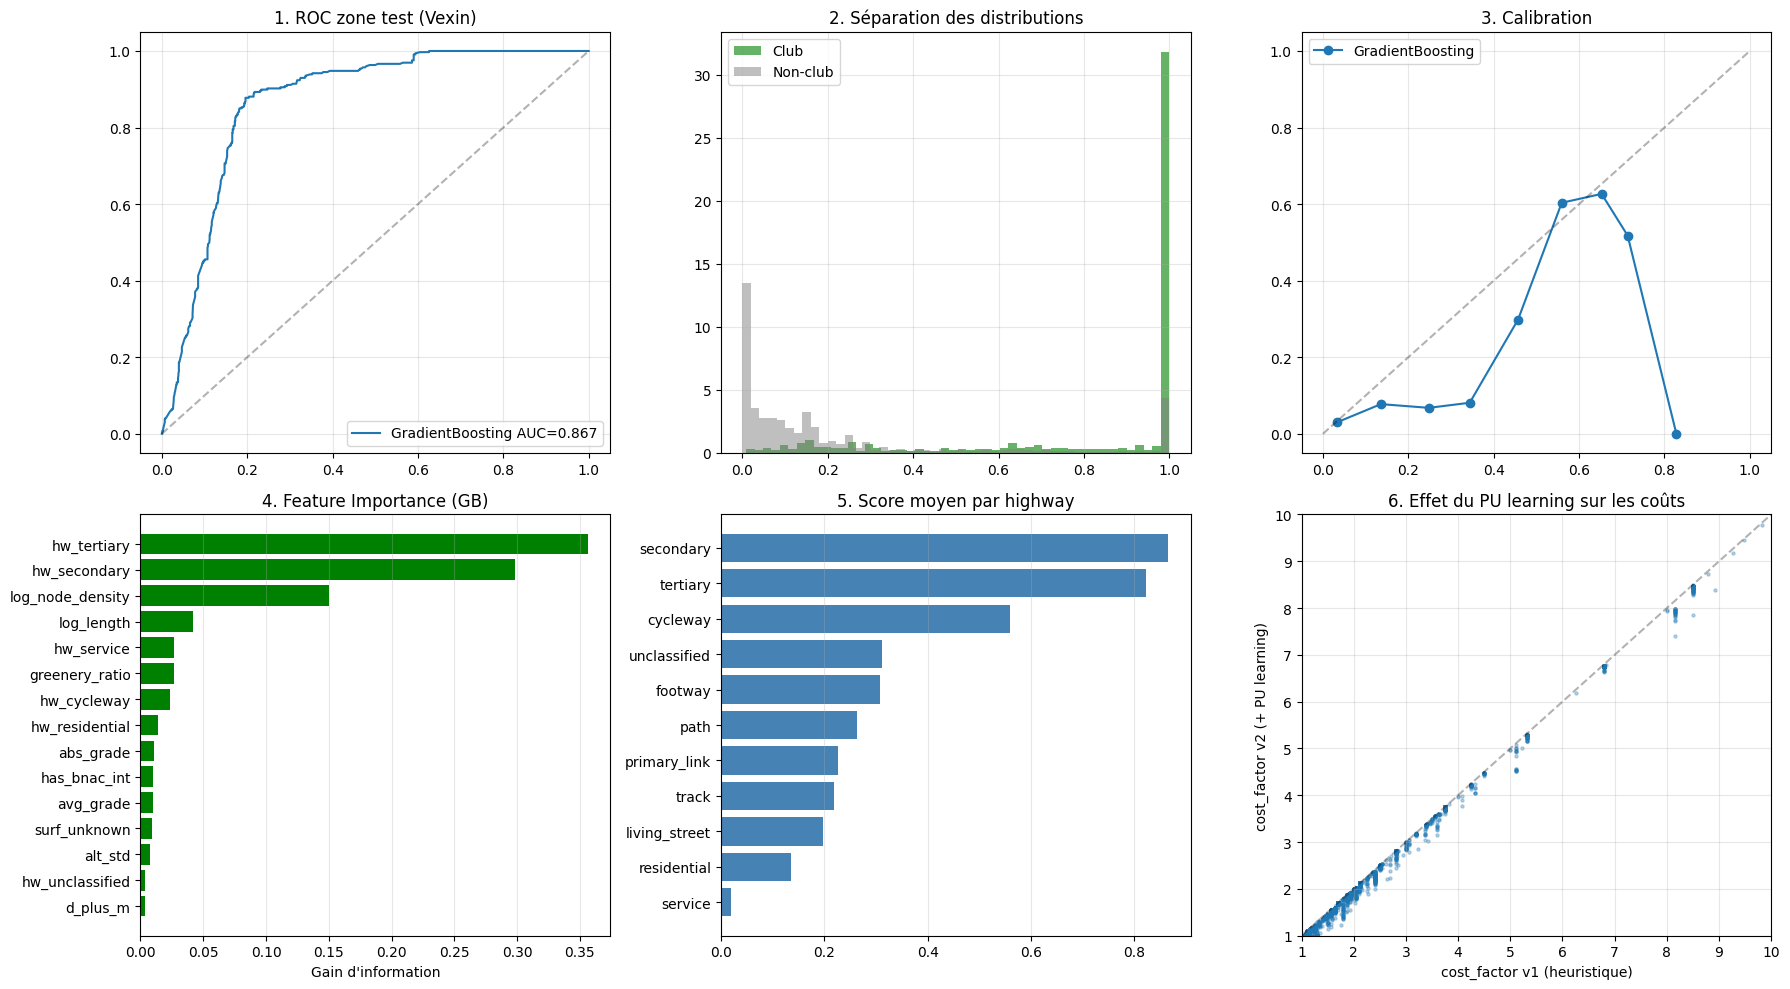


Résumé :
  AUC : 0.867
  Ratio séparation : 3.54
  c_hat : 0.451


In [12]:
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

proba_test_best = proba_test_gb if best_name == "GradientBoosting" else proba_test_lr

# 1. ROC
fpr, tpr, _ = roc_curve(y_test, proba_test_best)
axes[0,0].plot(fpr, tpr, label=f"{best_name} AUC={max(auc_lr, auc_gb):.3f}")
axes[0,0].plot([0,1],[0,1],"k--",alpha=0.3)
axes[0,0].set_title("1. ROC zone test (Vexin)")
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# 2. Distribution scores
axes[0,1].hist(df.loc[df.is_club==1,"score_club_gen"], bins=50, alpha=0.6, 
               label="Club", color="green", density=True)
axes[0,1].hist(df.loc[df.is_club==0,"score_club_gen"], bins=50, alpha=0.5,
               label="Non-club", color="gray", density=True)
axes[0,1].set_title("2. Séparation des distributions")
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# 3. Calibration
prob_true, prob_pred = calibration_curve(y_test, proba_test_best, n_bins=10)
axes[0,2].plot(prob_pred, prob_true, "o-", label=best_name)
axes[0,2].plot([0,1],[0,1],"k--",alpha=0.3)
axes[0,2].set_title("3. Calibration")
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

# 4. Feature Importance (Adapté pour GradientBoosting)
if best_name == "GradientBoosting":
    # On récupère l'importance des variables depuis l'estimateur calibré
    # (On prend le premier classifieur du CalibratedClassifierCV)
    importances = gb_cal.calibrated_classifiers_[0].estimator.feature_importances_
    
    imp = pd.DataFrame({"feature": FEATURES, "importance": importances})
    # On trie les 15 variables les plus importantes
    imp = imp.sort_values("importance", ascending=True).tail(15)
    
    axes[1,0].barh(imp["feature"], imp["importance"], color="green")
    axes[1,0].set_title("4. Feature Importance (GB)")
    axes[1,0].set_xlabel("Gain d'information")
    axes[1,0].grid(alpha=0.3, axis="x")

elif best_name == "LogReg":
    # Ton ancien code pour LogReg
    coefs = lr_cal.calibrated_classifiers_[0].estimator.coef_[0]
    imp = pd.DataFrame({"feature": FEATURES, "coef": coefs})
    imp = imp.sort_values("coef", key=abs, ascending=False).head(15).iloc[::-1]
    colors = ["green" if c > 0 else "red" for c in imp["coef"]]
    axes[1,0].barh(imp["feature"], imp["coef"], color=colors)
    axes[1,0].set_title("4. Top features (coefficient)")
    axes[1,0].grid(alpha=0.3, axis="x")

# 5. Score vs highway
hw_scores = df.groupby("highway")["score_club_gen"].agg(["mean", "count"])
hw_scores = hw_scores[hw_scores["count"] > 1000].sort_values("mean")
axes[1,1].barh(hw_scores.index, hw_scores["mean"], color="steelblue")
axes[1,1].set_title("5. Score moyen par highway")
axes[1,1].grid(alpha=0.3, axis="x")

# 6. Cost factor v1 vs v2
ax = axes[1,2]
with engine.connect() as conn:
    comp = pd.read_sql(text("""
        SELECT cost_factor_club, cost_factor_v2_club FROM edge_scores
        WHERE cost_factor_club IS NOT NULL
        ORDER BY RANDOM() LIMIT 10000;
    """), conn)
ax.scatter(comp["cost_factor_club"], comp["cost_factor_v2_club"], alpha=0.3, s=5)
ax.plot([1, 10], [1, 10], "k--", alpha=0.3)
ax.set_xlabel("cost_factor v1 (heuristique)")
ax.set_ylabel("cost_factor v2 (+ PU learning)")
ax.set_title("6. Effet du PU learning sur les coûts")
ax.set_xlim(1, 10); ax.set_ylim(1, 10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRésumé :")
print(f"  AUC : {max(auc_lr, auc_gb):.3f}")
print(f"  Ratio séparation : {m_p/m_u:.2f}")
print(f"  c_hat : {c_hat:.3f}")

## 8. Rapport final

In [25]:
print("=" * 70)
print("RAPPORT NOTEBOOK 5 v2")
print("=" * 70)

with engine.connect() as conn:
    rep = pd.read_sql(text("""
        SELECT
            (SELECT COUNT(*) FROM osm_edges WHERE d_plus_m IS NOT NULL) AS with_dplus,
            (SELECT AVG(d_plus_m)::numeric(10,2) FROM osm_edges WHERE d_plus_m > 0) AS avg_dplus,
            (SELECT COUNT(*) FROM edge_scores WHERE score_club_gen > 0.5) AS score_gen_05,
            (SELECT COUNT(*) FROM edge_scores WHERE score_club_gen > 0.7) AS score_gen_07,
            (SELECT AVG(cost_factor_club)::numeric(10,2) FROM edge_scores) AS cf_v1_mean,
            (SELECT AVG(cost_factor_v2_club)::numeric(10,2) FROM edge_scores) AS cf_v2_mean
    """), conn)
print(rep.T)
print(f"\nAUC test : {max(auc_lr, auc_gb):.3f}")
print(f"Modèle   : {best_name}")
print("=" * 70)

RAPPORT NOTEBOOK 5 v2
                      0
with_dplus    506169.00
avg_dplus          4.41
score_gen_05   77628.00
score_gen_07   55939.00
cf_v1_mean         1.61
cf_v2_mean         1.59

AUC test : 0.897
Modèle   : GradientBoosting


## Ce qu'on a accompli

✓ Données d'élévation SRTM intégrées
✓ D+, grade, alt_std calculés pour chaque arête
✓ PU Learning avec features adaptées (pas de coordonnées géographiques)
✓ Elkan-Noto pour calibrer les probabilités
✓ `score_club_gen` qui **complète** l'heuristique (pas remplace)
✓ `cost_factor_v2` qui pondère l'heuristique par le modèle appris

## Prochaine étape : Notebook 4 mis à jour

Tu peux maintenant revenir au Notebook 4 et remplacer `cost_factor_club`
par `cost_factor_v2_club` dans la requête SQL d'extraction. Tu verras une
amélioration du routing notamment sur les zones hors-club (Vexin, etc.).

## Limitations

- **SCAR assumption** toujours en place (labellisation indépendante des features,
  ce qui n'est pas 100% vrai)
- **Pas de météo** (future extension via feedback utilisateurs)
- **β fixé à 0.3** : pourrait être ajusté par validation croisée si les
  utilisateurs remontent du feedback
